In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import signal

## Opgave 1 {-}

### 1. {-}

#### (a) {-}

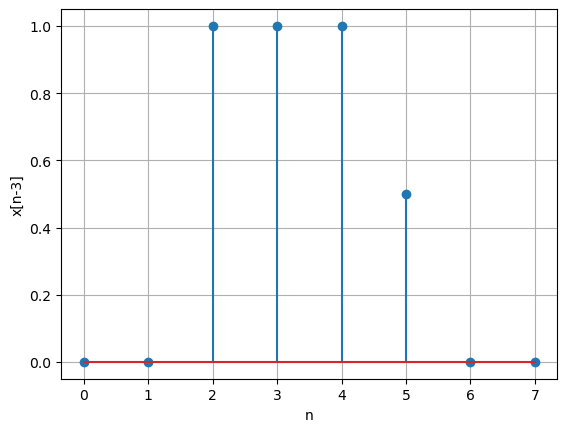

In [ ]:
n = np.arange(-3,5)
x = np.array([0,0,1,1,1,1/2,0,0])
plt.stem(n+3, x)
plt.xlabel('n')
plt.ylabel('$x[n-3]$')
plt.grid(True)

Dette er en tidsforsinket version af x

#### (b) {-}

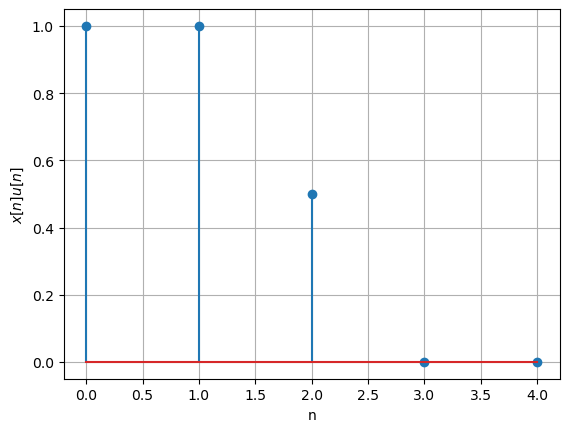

In [34]:
n = np.arange(0,5)
x = np.array([1,1,1/2,0,0])
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('$x[n]u[n]$')
plt.grid(True)

Multiplikation med enhedsstepfunktionen fjerner alt før 0.

### (c) {-}

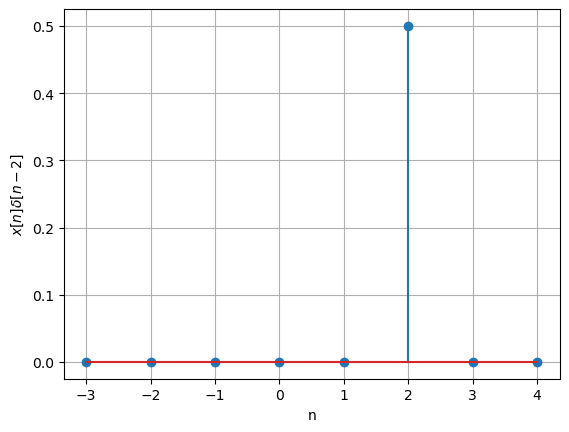

In [43]:
n = np.arange(-3,5)
x = np.array([0,0,0,0,0,1/2,0,0])
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('$x[n]\delta[n-2]$')
plt.grid(True)

Multiplikation med Dirac deltafunktionen vil udvælge et specifik punkt, i dette tilfælde n=2.

#### (d) {-}

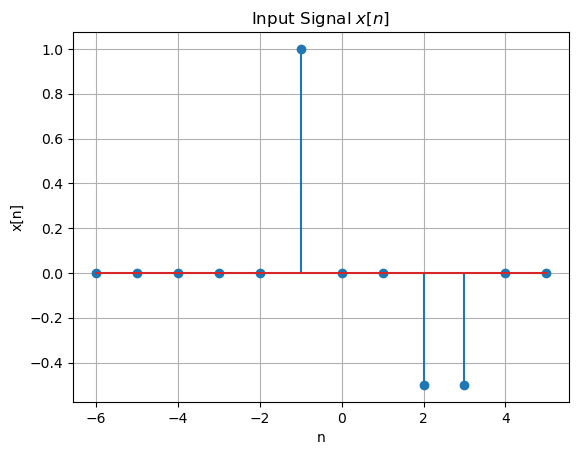

In [ ]:
n = np.arange(-6,6)
x = np.array([0,0,1,1,1,1/2,0,0])
x = np.convolve(x,[0,0,0,1,-1])
plt.stem(n, x)
plt.title('Input Signal $x[n]$')
plt.xlabel('n')
plt.ylabel('h[n]*x[n]')
plt.grid(True)

Dette giver $x[n] - x[n-1]$

#### (e) {-}

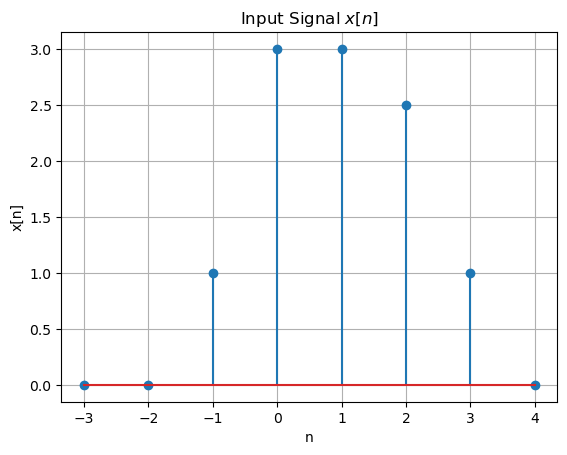

In [40]:
n = np.arange(-3,5)
x = np.array([0,0,1,1,1,1/2,0,0])
ny = 2*np.array([0,0,0,1,1,1,1/2,0])
x = x+ny
x
plt.stem(n, x)
plt.title('Input Signal $x[n]$')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)

Det her er signalet lagt oveni i dens tidsforskudte og skalerede version.

#### (f) {-}

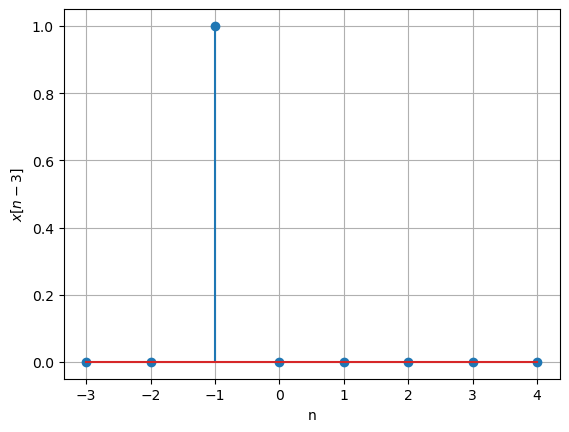

In [44]:
n = np.arange(-3,5)
x = np.array([0,0,1,0,0,0,0,0])
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('$x[n-3]$')
plt.grid(True)

Multiplikation med denne tidsforsinkede spejlvendte enhedsstepfunktion vil fjerne alt efter -1.

#### (g) {-}

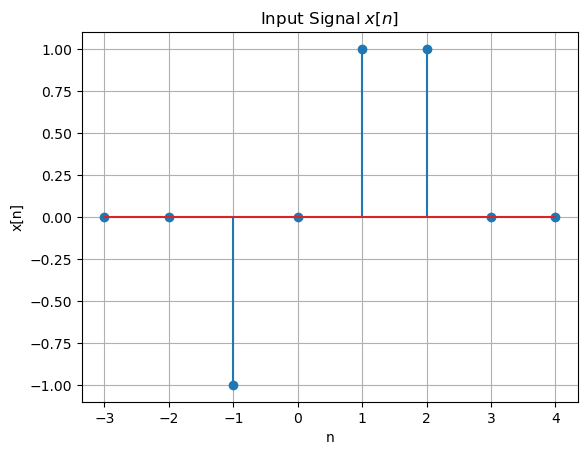

In [12]:
n = np.arange(-3,5)
x = np.array([0,0,1,1,1,1/2,0,0])
plt.stem(n, n*x)
plt.title('Input Signal $x[n]$')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)

Dette er det originale signal, men skaleret med n.

### 2. {-}

For at være lineært skal det overholde superpositionsprincippet. En lineær kombination af inputtet ville give dette output
$$
y[n] = a \cdot nx_{1}[n] + b \cdot nx_{2}[n]
$$

En lineær kombination af output ville svare til dette udtryk

\begin{align*}
y[n] &= a \cdot y_{1}[n] + b \cdot y_{2}[n]\\
&= a \cdot (n x_{1}[n]) + b \cdot (n x_{2}[n])\\
&= a \cdot nx_{1}[n] + b \cdot nx_{2}[n]
\end{align*}

Da udtrykken er det samme, er systemet lineært.

En tidsforsinkelse i inputtet ville give følgende output
$$
y[n] = nx[n-n_{0}]
$$

En tidsforsinkelse i outputtet ville svare til følgende udtryk

\begin{align*}
y[n-n_{0}] &= (n-n_{0})x[n-n_{0}]\\
&\neq nx[n-n_{0}]
\end{align*}

Da udtrykken ikke er det samme er systemet ikke tidsinvariant.

Det er altså et lineært med ikke tidsinvariant system.

## Opgave 2 {-}

### 1. {-}

Begge filtre er som beskrevet til midling, og tager begge en middelværdi af 3 punkter. $y_I[n]$ vægter alle punkter lige højt og sigter derfor efter at medtage omkringliggende information. $y_{II}[n]$ vægter den midterste værdi højst og sigter efter at medtage lidt omkringliggende information, men nedsænke det ved at halvere betydningen. Dette kan ses i nedenstående magnituderespons, hvor $y_I[n]$ har to små toppunkter for omkringliggende frekvenser, mens $y_{II}[n]$ kun har et enkelt toppunkt.

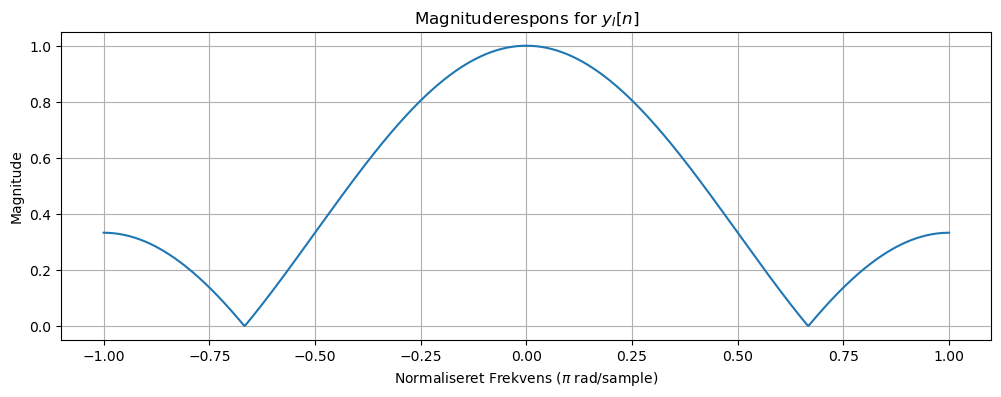

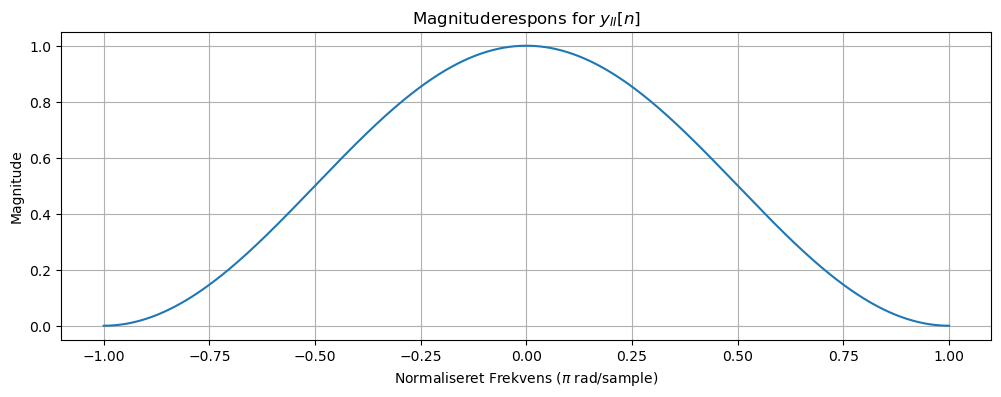

In [14]:
num = [1/3, 1/3, 1/3]
den = [1]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.plot(w / np.pi, np.abs(H))
plt.title('Magnituderespons for $y_I[n]$')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude')
plt.grid(True)

num = [1/4, 1/2, 1/4]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.plot(w / np.pi, np.abs(H))
plt.title('Magnituderespons for $y_{II}[n]$')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.show()

### 2. {-}

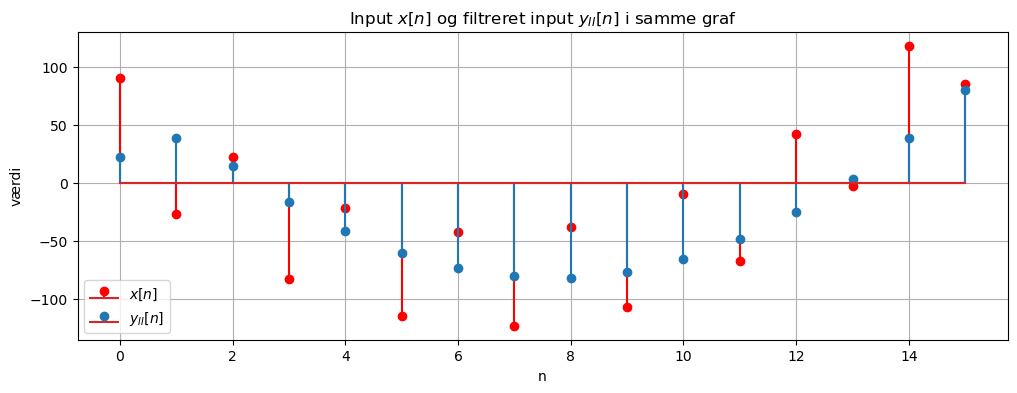

In [25]:
x = np.array([90, -27, 22, -83, -22, -115, -42, -123, -38, -107, -10, -67, 42, -3, 118, 85])
y = signal.lfilter(num, den, x)

plt.figure(figsize=(12, 4))

plt.stem(x, linefmt="r", label="$x[n]$")
plt.stem(y, label="$y_{II}[n]$")
plt.title('Input $x[n]$ og filtreret input $y_{II}[n]$ i samme graf')
plt.xlabel('n')
plt.ylabel('værdi')
plt.grid(True)
plt.legend()
plt.show()

Det kan ses at det røde input nogenlunde følger en bølge form, men at ca. hver anden datapunkt er meget mindre. Det blå filtrerede output gør bølgen mere continuer og blød, hvor signalet ligger på en værdi mellem de ekstremer fra det røde input.

## Opgave 3 {-}

### 1. {-}

Det kan ses i tabel 10.3 at et Hann vindue vil kunne overholde krav på $A_p = 0.055 dB$ og $A_s = 44 dB$, hvilket er perfekt til dette filter med lidt til overs. Det giver mening da Hann vinduet har en ok høj opløsning og med hurtigt uddøende ripples, som heller ikke er for store, hvilket passer god til et lavpasfilter.

### 2. {-}

$M$ kan estimeres ud fra tabel 10.3
$$
\Delta\omega = \omega_s - \omega_p = 0.05 \pi
$$
$$
0.05\pi = \frac{6.2\pi}{L} \Leftrightarrow L = 124
$$
$$
M = 125
$$

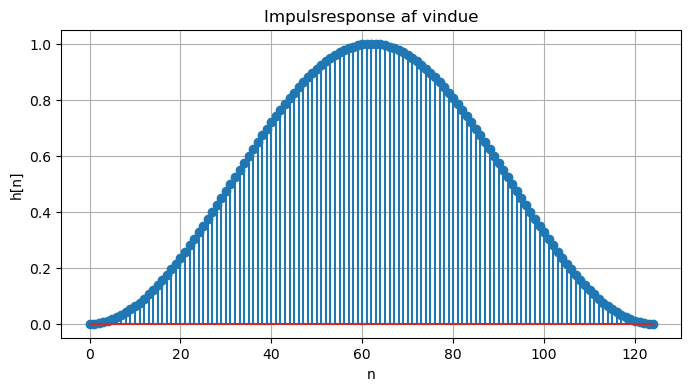

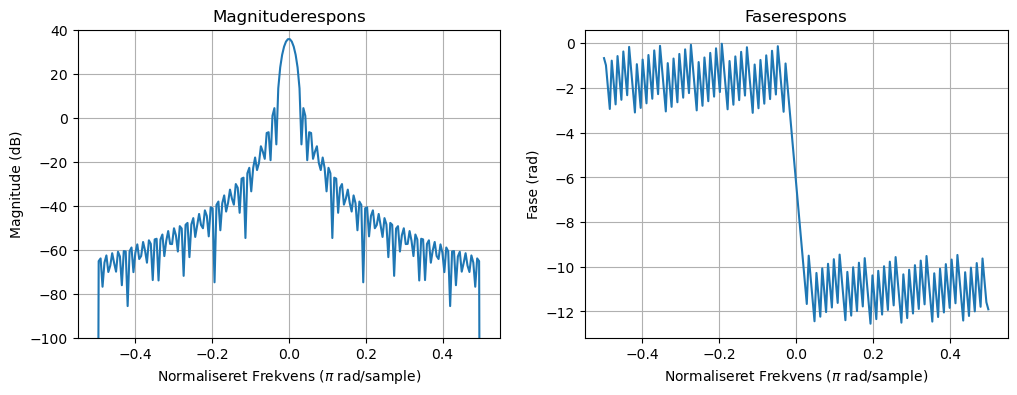

In [26]:
M = 125
h = np.hanning(M)
plt.figure(figsize=(8, 4))
plt.stem(np.arange(M), h)
plt.title('Impulsresponse af vindue')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid(True)
plt.show()

w = np.linspace(-0.5*np.pi, 0.5*np.pi, 200)
_, H = signal.freqz(h, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnituderespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-100, 40)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(H)))
plt.title('Faserespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()

Det kan ses at magnituderesponsen næsten når op til 40 dB, hvilket passer godt med designkravene. Den er allerede sænket en del inden den når passbåndsfrekvensen, men det betyder at hvertfald når de 0.2 dB fra kravene.

### 3. {-}

Dette ville gøre overgangen fra pass- til stopbånd utrolig skarp, da der mellem de to frekvenser kun er
$$
\Delta\omega = \omega_s - \omega_p = 0.01 \pi
$$

Resultat bliver en meget høj opløsning med ubetydelige ripples, men det betyder også at den praktisk talt slet ikke tager højde for omkringliggende data, når den laver vinduet, hvilket ikke ville midle overhovedet, hvilket kunne få det til at føles diskontinuert. Finder man den nye M værdi og plotter frekvensresponset igen, kan denne meget skarpe og høje opløsning også ses.
$$
0.01\pi = \frac{6.2\pi}{L} \Leftrightarrow L = 620
$$
$$
M = 621
$$

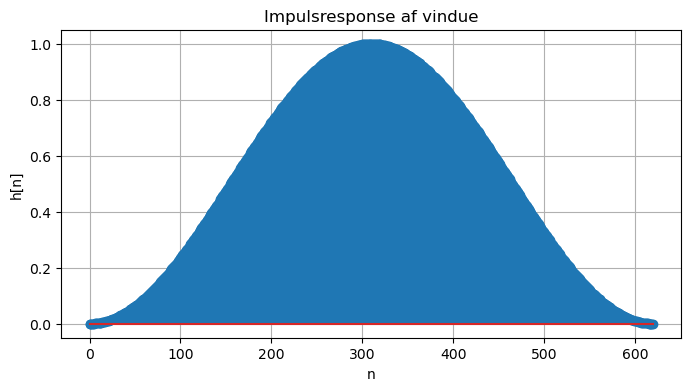

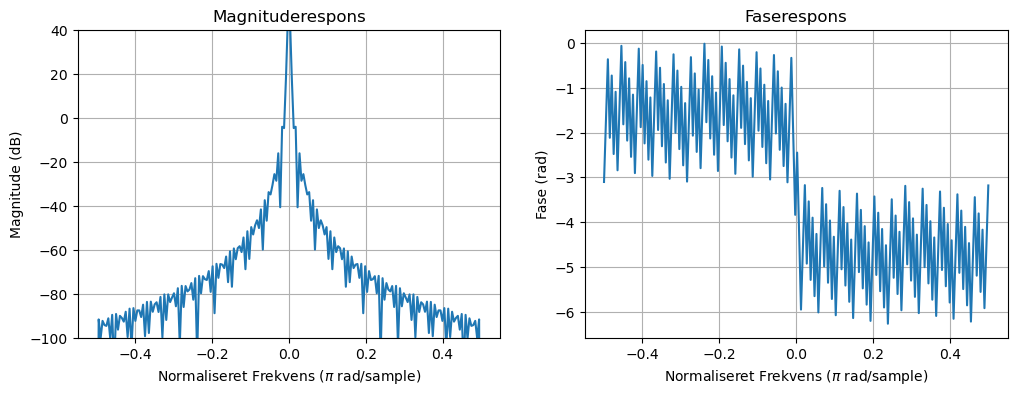

In [ ]:
M = 621
h = np.hanning(M)

w = np.linspace(-0.5*np.pi, 0.5*np.pi, 200)
_, H = signal.freqz(h, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnituderespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-100, 40)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(H)))
plt.title('Faserespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()

## Opgave 4 {-}

### 1. {-}

Beregning af $y[0]$

\begin{align*}
y[0] &= \frac{3}{4} y[-1] - \frac{1}{4} y[-2] + x[0]\\
&= \frac{3}{4} \cdot 0 - \frac{1}{4} \cdot 0 + 1\\
&= 1
\end{align*}

Beregning af $y[1]$

\begin{align*}
y[1] &= \frac{3}{4} y[0] - \frac{1}{4} y[-1] + x[1]\\
&= \frac{3}{4} \cdot 1 - \frac{1}{4} \cdot 0 - 2\\
&= -\frac{5}{4}
\end{align*}

Beregning af $y[2]$

\begin{align*}
y[2] &= \frac{3}{4} y[1] - \frac{1}{4} y[0] + x[2]\\
&= \frac{3}{4} \cdot (-\frac{5}{4}) - \frac{1}{4} \cdot 1 + 3\\
&= \frac{29}{16}
\end{align*}

Beregning af $y[3]$

\begin{align*}
y[3] &= \frac{3}{4} y[2] - \frac{1}{4} y[1] + x[3]\\
&= \frac{3}{4} \cdot \frac{29}{16} - \frac{1}{4} \cdot (-\frac{5}{4}) + 0\\
&= \frac{107}{64}
\end{align*}

### 2. {-}

\begin{align*}
Y(z) &= \frac{3}{4} z^{-1} Y(z) - \frac{1}{4} z^{-2} Y(z) + X(z)\\
Y(z) - \frac{3}{4} z^{-1} Y(z) + \frac{1}{4} z^{-2} Y(z) &= X(z)\\
H(z) = \frac{Y(z)}{X(z)} &= \frac{1}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}}
\end{align*}

Polen af systemet kan findes ved at opstille et karakteristisk polynomium
$$
\frac{1}{4}x^{2} - \frac{3}{4} x + 1
$$

Rødderne kan findes vha. wolfram alpha

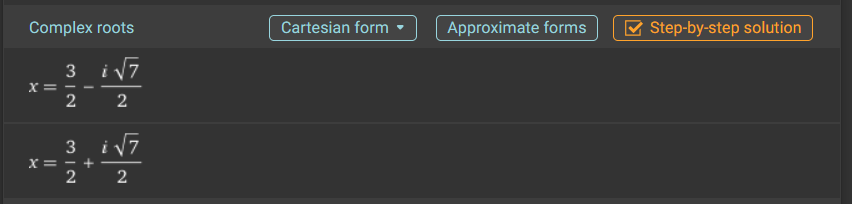

Som det kan ses er polen i dette tilfælde komplekst. Denne pol har størrelsen

In [46]:
np.abs(3/2 + 1j * np.sqrt(7)/2)

2.0

Da systemet er kausalt vil konvergensen være
$$
ROC: |z| > 2
$$

### 3. {-}

Systemet har ingen nulpunkter, men har de to komplekse poler fra før. Plottes dette fås følgende

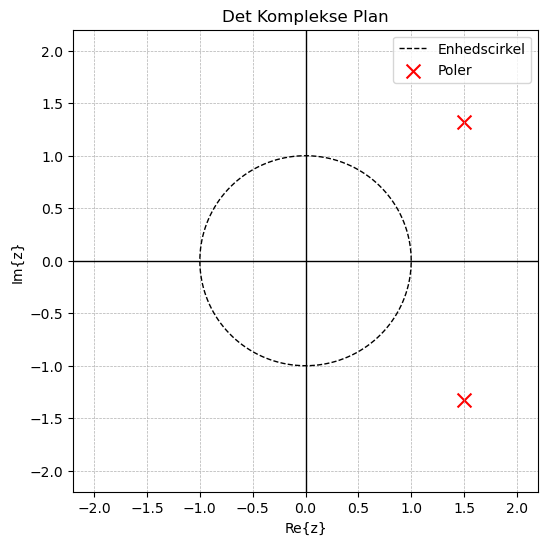

In [51]:
poles = np.array([3/2 - 1j * np.sqrt(7)/2, 3/2 + 1j * np.sqrt(7)/2])

# Plot setup
fig, ax = plt.subplots(figsize=(6,6))
ax.axhline(0, color='black', linewidth=1)  # X-axis
ax.axvline(0, color='black', linewidth=1)  # Y-axis
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_xlabel("Re{z}")
ax.set_ylabel("Im{z}")
ax.set_title("Det Komplekse Plan")

# Plot unit circle
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1, label="Enhedscirkel")

# Plot poles (red crosses)
ax.scatter(poles.real, poles.imag, marker='x', color='r', s=100, label="Poler")

# Legend and grid
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5)

# Show the plot
plt.show()


Det kan ses at polerne ligger udenfor enhedscirklen, hvilket betyder at systemet ikke er BIBO-stabilt.

### 4. {-}

Kaskade koblingen mellem de to systemer kan beskrives som produktet af deres systemfunktioner $H(z)$ og $G(z)$, hvor den første er fundet i opgave 4.2 og den anden er

\begin{align*}
Y(z) &= X(z) - \gamma z^{-1} X(z)\\
G(z) = \frac{Y(z)}{X(z)} &= 1 - \gamma z^{-1}
\end{align*}

Det koblede system er da

$$
H(z) \cdot G(z) = \frac{1}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}} (1 - \gamma z^{-1})
$$

For at gøre et IIR system til et FIR system kan man fjerne dets poler, og dermed fjerne feedback i systemet. Dette kan gøres, hvis der er et reelt tal som får $G(z)$ faktoren til at gå ud med nævneren, men da $G(z)$ er et første ordens system og $H(z)$ er et andet ordens system, ville det ikke kunne lade sig gøre. Kaskadekoblingen mellem T og S kan da ikke gøres til et system med endeligt impulssvar. Rækkefølgen burde ikke gøre nogen forskel, da foldning og multiplikation begge er kommutative. 

### 5. {-}

Parallelkoblingen mellem systemerne kan findes som summen af deres systemfunktioner

\begin{align*}
H(z) + G(z) &= \frac{1}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}} + (1 - \gamma z^{-1})\\
&= \frac{1}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}} + \frac{\left(1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}\right) \cdot (1 - \gamma z^{-1})}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}}\\
&= \frac{2 - \left( \gamma + \frac{3}{4} \right) z^{-1} + \frac{1}{4} z^{-2}}{1 - \frac{3}{4} z^{-1} + \frac{1}{4} z^{-2}}
\end{align*}

Dette er tæt på at gåd ud, men der findes stadig ingen relle værdier for $\gamma$ som vil fjerne alle poler. Parellelkoblingen af systemerne kan da heller ikke få et endeligt impulssvar.

## Opgave 5 {-}

### 1. {-}

Værdien som vil aliasere er værdien, som har en frekvens over halvdelen af samplingsfrekvensen, hvilket er delen med en frekvens på 1700 Hz. Den nye frekvens kan da bestemmes som
$$
F_a = F_s - F_0 = 3000 Hz - 1700 Hz = 1300 Hz
$$

### 2. {-}

\begin{align*}
x[n] &= x_{c}(n \cdot T_{s})\\
&= 0.7 \cdot \sin\left( 2\pi \cdot 400 \cdot n \cdot \frac{1}{3000} \right) + \cos\left( 2\pi \cdot 1300 Hz \cdot n \cdot \frac{1}{3000} \right)
\end{align*}

### 3. {-}

Valget af $g_r$ gør rekonstruktionen meget diskontinuær, da det blot er en zero order hold. Den komme til at holde på en sample værdi i kontinuær tid indtil næste sample, hvilket giver et upræcist signal. Derudover samples signalet stadig ikke indenfor nyquist kriteriet, hvilket medfører aliasing.

### 4. {-}

Dette valg af $g_r$ tager tid i betragtning, hvilket vil gøre det rekonstruerede signal kontinuært og overgangen mellem hver sample blødere. I første halvdel af samplingperioden vil hver sample blive ganget med $\frac{2}{T_s} \cdot t$, hvilket har formålet at benytte lidt af signalet i starten af sampleperioden da $\frac{2}{T_s} \cdot 0 = 0$ og benytte det fulde signal i midten af samplen da $\frac{2}{T_s} \cdot \frac{T_s}{2} = 1$. Den anden ende af samplen bliver så behandlet på samme måde men modsat, så slutningen af samplen bliver ganget med 0 og midten igen ganges med 1. Dette giver en mere glidende overgang som tidligere beskrevet.